In [181]:
# ---------- imports + global settings ----------

import numpy as np
import pandas as pd
import scipy
import scipy.stats
import scipy.optimize
import matplotlib.pyplot as plt
from IPython.display import display

seed = 42
rng = np.random.default_rng(seed)

Rmax = 1.0
response_sd_default = 0.18

num_x_default = 301
num_r_default = 251

n_starts_default = 12
maxiter_default = 150

n_steps_main = 5000
burn_in_main = 500

gamma_grid = np.linspace(0.0, 1.0, 9)

p_switch_main = 0.01
seed_list = [0, 1, 2, 3]

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [182]:
# ---------- default contexts ----------

contexts_mean_default = {
    0: {"name": "low-mean",  "mu": -2.0, "sigma": 1.0},
    1: {"name": "high-mean", "mu":  2.0, "sigma": 1.0},
}

contexts_var_default = {
    0: {"name": "low-var",  "mu": 0.0, "sigma": 0.7},
    1: {"name": "high-var", "mu": 0.0, "sigma": 1.8},
}

In [183]:
# ---------- environment constructors ----------

def make_mean_contexts(delta, sigma=1.0):
    half = delta / 2.0
    return {
        0: {"name": "low-mean",  "mu": -half, "sigma": sigma},
        1: {"name": "high-mean", "mu":  half, "sigma": sigma},
    }


def make_variance_contexts(sigma_low, sigma_high, mu=0.0):
    return {
        0: {"name": "low-var",  "mu": mu, "sigma": sigma_low},
        1: {"name": "high-var", "mu": mu, "sigma": sigma_high},
    }

In [184]:
# ---------- encoding and grid helpers ----------

def logistic(x, a, b, Rmax=Rmax):
    return Rmax / (1.0 + np.exp(-a * (x - b)))


def logistic_derivative(x, a, b, Rmax=Rmax):
    y = logistic(x, a, b, Rmax=Rmax)
    return a * y * (1 - y / Rmax)


def make_x_grid(contexts, n_std=5, num_x=num_x_default):
    mus = [c["mu"] for c in contexts.values()]
    sigmas = [c["sigma"] for c in contexts.values()]

    x_min = min(mu - n_std * sigma for mu, sigma in zip(mus, sigmas))
    x_max = max(mu + n_std * sigma for mu, sigma in zip(mus, sigmas))

    pad = 0.5
    return np.linspace(x_min - pad, x_max + pad, num_x)


def normal_pmf_on_grid(x_grid, mu, sigma):
    px = scipy.stats.norm.pdf(x_grid, loc=mu, scale=sigma)
    px = np.maximum(px, 1e-300)
    px /= px.sum()
    return px


def mixture_prior_pmf(contexts, x_grid, weights=None):
    keys = list(contexts.keys())

    if weights is None:
        weights = {k: 1.0 / len(keys) for k in keys}

    px = np.zeros_like(x_grid, dtype=float)

    for k in keys:
        px += weights[k] * normal_pmf_on_grid(
            x_grid,
            contexts[k]["mu"],
            contexts[k]["sigma"],
        )

    px = np.maximum(px, 1e-300)
    px /= px.sum()
    return px

In [185]:
# ---------- posterior and decoding helpers ----------

def posterior_stats_from_prior_one_neuron(
    x_grid,
    px,
    a,
    b,
    response_sd=response_sd_default,
    Rmax=Rmax,
    num_r=num_r_default,
):
    mean_responses = logistic(x_grid, a, b, Rmax=Rmax)

    r_min = mean_responses.min() - 4 * response_sd
    r_max = mean_responses.max() + 4 * response_sd
    r_grid = np.linspace(r_min, r_max, num_r)

    pr_given_x_density = scipy.stats.norm.pdf(
        r_grid[None, :],
        loc=mean_responses[:, None],
        scale=response_sd,
    )
    pr_given_x_density = np.maximum(pr_given_x_density, 1e-300)

    pr_given_x = pr_given_x_density / pr_given_x_density.sum(axis=1, keepdims=True)

    p_r = np.sum(px[:, None] * pr_given_x, axis=0)
    p_r = np.maximum(p_r, 1e-300)
    p_r /= p_r.sum()

    posterior = (pr_given_x * px[:, None]) / p_r[None, :]
    posterior = np.maximum(posterior, 1e-300)
    posterior /= posterior.sum(axis=0, keepdims=True)

    posterior_mean = np.sum(posterior * x_grid[:, None], axis=0)

    bayes_mse = np.sum(
        px[:, None] * pr_given_x * (posterior_mean[None, :] - x_grid[:, None]) ** 2
    )

    return {
        "x_grid": x_grid,
        "px": px,
        "a": a,
        "b": b,
        "mean_responses": mean_responses,
        "r_grid": r_grid,
        "pr_given_x_density": pr_given_x_density,
        "pr_given_x": pr_given_x,
        "p_r": p_r,
        "posterior": posterior,
        "posterior_mean": posterior_mean,
        "bayes_mse": bayes_mse,
    }


def posterior_stats_one_neuron(
    context,
    a,
    b,
    x_grid,
    response_sd=response_sd_default,
    Rmax=Rmax,
    num_r=num_r_default,
):
    px = normal_pmf_on_grid(x_grid, context["mu"], context["sigma"])
    return posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px,
        a=a,
        b=b,
        response_sd=response_sd,
        Rmax=Rmax,
        num_r=num_r,
    )


def decoded_mean_given_x_from_stats(stats):
    x_grid = stats["x_grid"]
    pr_given_x = stats["pr_given_x"]
    xhat_r = stats["posterior_mean"]

    decoded_mean_given_x = np.sum(pr_given_x * xhat_r[None, :], axis=1)
    bias_given_x = decoded_mean_given_x - x_grid
    local_mse_given_x = np.sum(
        pr_given_x * (xhat_r[None, :] - x_grid[:, None]) ** 2,
        axis=1,
    )

    return {
        "x_grid": x_grid,
        "decoded_mean_given_x": decoded_mean_given_x,
        "bias_given_x": bias_given_x,
        "local_mse_given_x": local_mse_given_x,
    }


def interp_from_package(r, package, field):
    vals = package[field]
    grid = package["r_grid"]
    return np.interp(r, grid, vals, left=vals[0], right=vals[-1])


def predictive_density(r, package, response_sd=response_sd_default):
    density = np.sum(
        package["px"] * scipy.stats.norm.pdf(
            r,
            loc=package["mean_responses"],
            scale=response_sd,
        )
    )
    return max(float(density), 1e-300)

In [186]:
# ---------- objectives ----------

def specialized_mse_objective(params, context, x_grid, response_sd=response_sd_default):
    a, b = params

    if a <= 0:
        return np.inf

    stats = posterior_stats_one_neuron(
        context=context,
        a=a,
        b=b,
        x_grid=x_grid,
        response_sd=response_sd,
    )
    return stats["bayes_mse"]


def static_mse_objective(params, contexts, x_grid, response_sd=response_sd_default):
    a, b = params

    if a <= 0:
        return np.inf

    px_mix = mixture_prior_pmf(contexts, x_grid)
    stats = posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px_mix,
        a=a,
        b=b,
        response_sd=response_sd,
    )
    return stats["bayes_mse"]


def context_inference_metrics(
    params,
    contexts,
    x_grid,
    response_sd=response_sd_default,
    context_weights=None,
):
    a, b = params

    if a <= 0:
        return {
            "conditional_entropy": np.inf,
            "map_accuracy": -np.inf,
        }

    mean_responses = logistic(x_grid, a, b, Rmax=Rmax)

    r_min = mean_responses.min() - 4 * response_sd
    r_max = mean_responses.max() + 4 * response_sd
    r_grid = np.linspace(r_min, r_max, num_r_default)

    pr_given_x_density = scipy.stats.norm.pdf(
        r_grid[None, :],
        loc=mean_responses[:, None],
        scale=response_sd,
    )
    pr_given_x_density = np.maximum(pr_given_x_density, 1e-300)
    pr_given_x = pr_given_x_density / pr_given_x_density.sum(axis=1, keepdims=True)

    keys = list(contexts.keys())

    if context_weights is None:
        p_context = {k: 1.0 / len(keys) for k in keys}
    else:
        p_context = {k: float(context_weights[k]) for k in keys}
        z = sum(p_context.values())
        p_context = {k: p_context[k] / z for k in keys}

    p_r_given_context = {}
    for k, context in contexts.items():
        px = normal_pmf_on_grid(x_grid, context["mu"], context["sigma"])
        p_r = np.sum(px[:, None] * pr_given_x, axis=0)
        p_r = np.maximum(p_r, 1e-300)
        p_r /= p_r.sum()
        p_r_given_context[k] = p_r

    p_r_total = np.zeros_like(r_grid, dtype=float)
    for k in keys:
        p_r_total += p_context[k] * p_r_given_context[k]
    p_r_total = np.maximum(p_r_total, 1e-300)
    p_r_total /= p_r_total.sum()

    posterior_mat = []
    conditional_entropy = 0.0

    for k in keys:
        p_c_given_r = (p_context[k] * p_r_given_context[k]) / p_r_total
        p_c_given_r = np.maximum(p_c_given_r, 1e-300)
        posterior_mat.append(p_c_given_r)

        conditional_entropy += -p_context[k] * np.sum(
            p_r_given_context[k] * np.log(p_c_given_r)
        )

    posterior_mat = np.vstack(posterior_mat)
    map_accuracy = float(np.sum(p_r_total * np.max(posterior_mat, axis=0)))

    return {
        "conditional_entropy": float(conditional_entropy),
        "map_accuracy": map_accuracy,
    }


def context_accuracy_objective(
    params,
    contexts,
    x_grid,
    response_sd=response_sd_default,
    context_weights=None,
):
    metrics = context_inference_metrics(
        params=params,
        contexts=contexts,
        x_grid=x_grid,
        response_sd=response_sd,
        context_weights=context_weights,
    )
    return -metrics["map_accuracy"]

In [187]:
# ---------- optimizer helper ----------

def fit_multistart(
    obj,
    bounds,
    n_starts=n_starts_default,
    seed=0,
    maxiter=maxiter_default,
):
    rng_local = np.random.default_rng(seed)
    best_res = None

    for _ in range(n_starts):
        x0 = np.array([rng_local.uniform(lo, hi) for lo, hi in bounds])

        res = scipy.optimize.minimize(
            obj,
            x0=x0,
            method="Powell",
            bounds=bounds,
            options={
                "maxiter": maxiter,
                "xtol": 1e-3,
                "ftol": 1e-4,
                "disp": False,
            },
        )

        if (best_res is None) or (res.fun < best_res.fun):
            best_res = res

    return best_res

In [188]:
# ---------- fit codebook for arbitrary contexts ----------

def fit_codebook_for_contexts(
    contexts,
    seed_offset=0,
    response_sd=response_sd_default,
):
    x_grid = make_x_grid(contexts)
    bounds = [(0.25, 8.0), (x_grid.min(), x_grid.max())]

    fit_local = {}
    local_params = {}

    keys = list(contexts.keys())
    for idx, k in enumerate(keys):
        res = fit_multistart(
            lambda p, ck=k: specialized_mse_objective(
                p, contexts[ck], x_grid, response_sd=response_sd
            ),
            bounds=bounds,
            seed=1000 + seed_offset + idx,
        )
        fit_local[k] = res
        local_params[k] = res.x

    fit_static = fit_multistart(
        lambda p: static_mse_objective(p, contexts, x_grid, response_sd=response_sd),
        bounds=bounds,
        seed=1100 + seed_offset,
    )

    fit_infer_acc = fit_multistart(
        lambda p: context_accuracy_objective(
            p, contexts, x_grid, response_sd=response_sd
        ),
        bounds=bounds,
        seed=1200 + seed_offset,
    )

    static_params = fit_static.x
    infer_acc_params = fit_infer_acc.x

    nonlocal_target_params = {
        0: np.array(local_params[1], dtype=float),
        1: np.array(local_params[0], dtype=float),
    }

    return {
        "contexts": contexts,
        "x_grid": x_grid,
        "bounds": bounds,
        "local_params": local_params,
        "static_params": static_params,
        "infer_acc_params": infer_acc_params,
        "nonlocal_target_params": nonlocal_target_params,
        "fit_local": fit_local,
        "fit_static": fit_static,
        "fit_infer_acc": fit_infer_acc,
    }

In [189]:
# ---------- adaptive family helpers ----------

def blend_params(local_params, target_params, gamma):
    a_local, b_local = local_params
    a_target, b_target = target_params
    return np.array([
        (1 - gamma) * a_local + gamma * a_target,
        (1 - gamma) * b_local + gamma * b_target,
    ])


def target_for_context(target_params, context_key):
    if isinstance(target_params, dict):
        return np.asarray(target_params[context_key], dtype=float)
    return np.asarray(target_params, dtype=float)


def make_family_params(local_params, target_params, gamma):
    out = {}
    for k in local_params:
        out[k] = blend_params(
            np.asarray(local_params[k], dtype=float),
            target_for_context(target_params, k),
            gamma,
        )
    return out


def make_context_package(context, params, x_grid, response_sd=response_sd_default):
    a, b = params
    stats = posterior_stats_one_neuron(
        context=context,
        a=a,
        b=b,
        x_grid=x_grid,
        response_sd=response_sd,
    )
    return stats


def make_family_packages(contexts, family_params, x_grid, response_sd=response_sd_default):
    packages = {}
    for k in contexts:
        packages[k] = make_context_package(
            contexts[k],
            family_params[k],
            x_grid,
            response_sd=response_sd,
        )
    return packages

In [190]:
# ---------- online simulation helpers ----------

def sample_context_sequence(n_steps, p_switch, seed=0):
    rng_local = np.random.default_rng(seed)
    c = np.zeros(n_steps, dtype=int)
    c[0] = rng_local.integers(0, 2)

    for t in range(1, n_steps):
        if rng_local.random() < p_switch:
            c[t] = 1 - c[t - 1]
        else:
            c[t] = c[t - 1]
    return c

def make_likelihood_package(
    true_context,
    used_params,
    x_grid,
    response_sd=response_sd_default,
):
    a, b = used_params
    px = normal_pmf_on_grid(x_grid, true_context["mu"], true_context["sigma"])
    return posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px,
        a=a,
        b=b,
        response_sd=response_sd,
    )

def transition_matrix_from_switch_prob(p_switch):
    return np.array([
        [1 - p_switch, p_switch],
        [p_switch, 1 - p_switch],
    ])


def choose_context_with_hysteresis(prob_context_1, prev_estimated_context, tau_low, tau_high):
    """
    Hysteresis switching rule using P(context=1).

    If currently in context 0:
        switch to 1 only if P(1) > tau_high
    If currently in context 1:
        switch to 0 only if P(1) < tau_low
    Otherwise keep previous estimate.

    Requires tau_low <= tau_high.
    """
    if tau_low > tau_high:
        raise ValueError(f"Need tau_low <= tau_high, got tau_low={tau_low}, tau_high={tau_high}")

    if prev_estimated_context == 0:
        if prob_context_1 > tau_high:
            return 1
        return 0
    else:
        if prob_context_1 < tau_low:
            return 0
        return 1


def run_strategy_one_neuron(
    strategy_name,
    contexts,
    x_grid,
    local_params,
    static_params,
    target_params,
    gamma=0.0,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    seed=0,
    adaptation_mode="instant",      # "instant", "hysteresis", "refractory", "both"
    tau_low=0.35,                   # hysteresis lower threshold on P(context=1)
    tau_high=0.65,                  # hysteresis upper threshold on P(context=1)
    refractory_length=0,            # lockout length after a switch
):
    rng_local = np.random.default_rng(seed)
    transition_matrix = transition_matrix_from_switch_prob(p_switch)
    true_contexts = sample_context_sequence(n_steps, p_switch, seed=seed + 100)

    static_package = posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=mixture_prior_pmf(contexts, x_grid),
        a=static_params[0],
        b=static_params[1],
        response_sd=response_sd,
    )

    family_params = make_family_params(local_params, target_params, gamma)
    family_packages = make_family_packages(
        contexts, family_params, x_grid, response_sd=response_sd
    )
    local_packages = make_family_packages(
        contexts, local_params, x_grid, response_sd=response_sd
    )

    # likelihood packages indexed by:
    #   used encoder context -> hypothesized true context
    context_likelihood_packages = {}
    for used_k in contexts:
        context_likelihood_packages[used_k] = {}
        used_params_k = family_params[used_k]

        for true_k in contexts:
            context_likelihood_packages[used_k][true_k] = make_likelihood_package(
                true_context=contexts[true_k],
                used_params=used_params_k,
                x_grid=x_grid,
                response_sd=response_sd,
            )

    rows = []
    belief = np.array([0.5, 0.5], dtype=float)

    prev_estimated_context = 0
    refractory_timer = 0

    for t in range(n_steps):
        true_c = int(true_contexts[t])
        context = contexts[true_c]
        x_t = rng_local.normal(loc=context["mu"], scale=context["sigma"])

        if strategy_name == "static":
            used_params = np.asarray(static_params, dtype=float)
            used_package = static_package
            estimated_context = np.nan
            desired_context = np.nan
            desired_params = np.asarray(static_params, dtype=float)
            mismatch = False
            switch_locked = False

        elif strategy_name == "oracle":
            used_params = np.asarray(local_params[true_c], dtype=float)
            used_package = local_packages[true_c]
            estimated_context = true_c
            desired_context = true_c
            desired_params = np.asarray(local_params[true_c], dtype=float)
            mismatch = False
            switch_locked = False

        elif strategy_name == "adaptive":
            belief_pred = transition_matrix.T @ belief
            belief_pred /= belief_pred.sum()

            p_context_1 = float(belief_pred[1])

            uses_refractory = adaptation_mode in ["refractory", "both"]
            uses_hysteresis = adaptation_mode in ["hysteresis", "both"]

            switch_locked = uses_refractory and (refractory_timer > 0)

            if switch_locked:
                estimated_context = prev_estimated_context
                refractory_timer -= 1
            else:
                if uses_hysteresis:
                    estimated_context = choose_context_with_hysteresis(
                        prob_context_1=p_context_1,
                        prev_estimated_context=prev_estimated_context,
                        tau_low=tau_low,
                        tau_high=tau_high,
                    )
                else:
                    estimated_context = int(np.argmax(belief_pred))

                if uses_refractory:
                    if estimated_context != prev_estimated_context:
                        refractory_timer = refractory_length
                    else:
                        refractory_timer = 0

            desired_context = estimated_context
            desired_params = np.asarray(family_params[desired_context], dtype=float)

            used_params = desired_params.copy()
            used_package = family_packages[desired_context]
            mismatch = (estimated_context != true_c)

            prev_estimated_context = estimated_context

        else:
            raise ValueError(f"Unknown strategy_name: {strategy_name}")

        mean_r = logistic(x_t, used_params[0], used_params[1], Rmax=Rmax)
        r_t = rng_local.normal(loc=mean_r, scale=response_sd)

        xhat_t = interp_from_package(r_t, used_package, "posterior_mean")
        sq_error = (x_t - xhat_t) ** 2

        if strategy_name == "adaptive":
            used_encoder_context = desired_context

            likelihoods = np.array([
                predictive_density(
                    r_t,
                    context_likelihood_packages[used_encoder_context][0],
                    response_sd=response_sd,
                ),
                predictive_density(
                    r_t,
                    context_likelihood_packages[used_encoder_context][1],
                    response_sd=response_sd,
                ),
            ])

            belief = likelihoods * belief_pred
            belief_sum = belief.sum()
            if belief_sum <= 0:
                belief = np.array([0.5, 0.5], dtype=float)
            else:
                belief /= belief_sum

        rows.append({
            "t": t,
            "true_context": true_c,
            "estimated_context": estimated_context,
            "desired_context": desired_context,
            "x": x_t,
            "r": r_t,
            "xhat": xhat_t,
            "sq_error": sq_error,
            "mismatch": mismatch,
            "used_a": used_params[0],
            "used_b": used_params[1],
            "desired_a": desired_params[0] if strategy_name != "static" else np.nan,
            "desired_b": desired_params[1] if strategy_name != "static" else np.nan,
            "belief_context_1": belief[1] if strategy_name == "adaptive" else np.nan,
            "refractory_timer": refractory_timer if strategy_name == "adaptive" else np.nan,
            "switch_locked": switch_locked if strategy_name == "adaptive" else np.nan,
        })

    df = pd.DataFrame(rows)
    df_eval = df.iloc[burn_in:].copy()

    out = {
        "df": df,
        "global_mse": df_eval["sq_error"].mean(),
    }

    if strategy_name == "adaptive":
        mismatch_mask = df_eval["mismatch"].astype(bool).values
        matched = df_eval.loc[~df_eval["mismatch"], "sq_error"].values
        mismatched = df_eval.loc[df_eval["mismatch"], "sq_error"].values

        mismatch_lengths = []
        run_len = 0
        for m in mismatch_mask:
            if m:
                run_len += 1
            elif run_len > 0:
                mismatch_lengths.append(run_len)
                run_len = 0
        if run_len > 0:
            mismatch_lengths.append(run_len)

        out["mismatch_rate"] = df_eval["mismatch"].mean()
        out["matched_mse"] = matched.mean() if len(matched) > 0 else np.nan
        out["mismatched_mse"] = mismatched.mean() if len(mismatched) > 0 else np.nan
        out["mean_mismatch_duration"] = (
            np.mean(mismatch_lengths) if len(mismatch_lengths) > 0 else 0.0
        )

    return out

In [191]:
# ---------- evaluation helpers for final switching project ----------

def evaluate_baseline_strategies(
    contexts,
    x_grid,
    local_params,
    static_params,
    seeds=seed_list,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
):
    rows = []

    for seed_now in seeds:
        out_static = run_strategy_one_neuron(
            strategy_name="static",
            contexts=contexts,
            x_grid=x_grid,
            local_params=local_params,
            static_params=static_params,
            target_params=static_params,
            gamma=0.0,
            p_switch=p_switch,
            n_steps=n_steps,
            burn_in=burn_in,
            response_sd=response_sd,
            seed=seed_now,
        )

        out_oracle = run_strategy_one_neuron(
            strategy_name="oracle",
            contexts=contexts,
            x_grid=x_grid,
            local_params=local_params,
            static_params=static_params,
            target_params=static_params,
            gamma=0.0,
            p_switch=p_switch,
            n_steps=n_steps,
            burn_in=burn_in,
            response_sd=response_sd,
            seed=seed_now,
        )

        out_local = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts,
            x_grid=x_grid,
            local_params=local_params,
            static_params=static_params,
            target_params=static_params,
            gamma=0.0,
            p_switch=p_switch,
            n_steps=n_steps,
            burn_in=burn_in,
            response_sd=response_sd,
            seed=seed_now,
            adaptation_mode="instant",
        )

        rows.append({
            "strategy": "static",
            "seed": seed_now,
            "global_mse": out_static["global_mse"],
            "mismatch_rate": np.nan,
            "mean_mismatch_duration": np.nan,
            "mismatched_mse": np.nan,
        })
        rows.append({
            "strategy": "oracle",
            "seed": seed_now,
            "global_mse": out_oracle["global_mse"],
            "mismatch_rate": np.nan,
            "mean_mismatch_duration": np.nan,
            "mismatched_mse": np.nan,
        })
        rows.append({
            "strategy": "adaptive_local",
            "seed": seed_now,
            "global_mse": out_local["global_mse"],
            "mismatch_rate": out_local["mismatch_rate"],
            "mean_mismatch_duration": out_local["mean_mismatch_duration"],
            "mismatched_mse": out_local["mismatched_mse"],
        })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("strategy", as_index=False)
        .agg(
            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            mismatch_rate_mean=("mismatch_rate", "mean"),
            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
            mismatched_mse_mean=("mismatched_mse", "mean"),
        )
        .sort_values("global_mse_mean")
        .reset_index(drop=True)
    )

    return df, summary


def evaluate_switching_modes(
    contexts,
    x_grid,
    local_params,
    static_params,
    seeds=seed_list,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
):
    mode_specs = [
        ("instant", {"adaptation_mode": "instant", "tau_low": tau_low_default, "tau_high": tau_high_default, "refractory_length": 0}),
        ("hysteresis", {"adaptation_mode": "hysteresis", "tau_low": tau_low_default, "tau_high": tau_high_default, "refractory_length": 0}),
        ("refractory", {"adaptation_mode": "refractory", "tau_low": tau_low_default, "tau_high": tau_high_default, "refractory_length": refractory_default}),
    ]

    rows = []

    for mode_name, mode_kwargs in mode_specs:
        for seed_now in seeds:
            out = run_strategy_one_neuron(
                strategy_name="adaptive",
                contexts=contexts,
                x_grid=x_grid,
                local_params=local_params,
                static_params=static_params,
                target_params=static_params,
                gamma=0.0,
                p_switch=p_switch,
                n_steps=n_steps,
                burn_in=burn_in,
                response_sd=response_sd,
                seed=seed_now,
                adaptation_mode=mode_kwargs["adaptation_mode"],
                tau_low=mode_kwargs["tau_low"],
                tau_high=mode_kwargs["tau_high"],
                refractory_length=mode_kwargs["refractory_length"],
            )

            rows.append({
                "mode": mode_name,
                "seed": seed_now,
                "global_mse": out["global_mse"],
                "mismatch_rate": out["mismatch_rate"],
                "mean_mismatch_duration": out["mean_mismatch_duration"],
                "mismatched_mse": out["mismatched_mse"],
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("mode", as_index=False)
        .agg(
            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            mismatch_rate_mean=("mismatch_rate", "mean"),
            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
            mismatched_mse_mean=("mismatched_mse", "mean"),
        )
        .reset_index(drop=True)
    )

    return df, summary

In [192]:
# ---------- default codebook fits ----------

fit_mean = fit_codebook_for_contexts(contexts_mean_default, seed_offset=0)
fit_var = fit_codebook_for_contexts(contexts_var_default, seed_offset=500)

x_grid_mean = fit_mean["x_grid"]
local_params_mean = fit_mean["local_params"]
static_params_mean = fit_mean["static_params"]
infer_acc_params_mean = fit_mean["infer_acc_params"]
nonlocal_target_params_mean = fit_mean["nonlocal_target_params"]

x_grid_var = fit_var["x_grid"]
local_params_var = fit_var["local_params"]
static_params_var = fit_var["static_params"]
infer_acc_params_var = fit_var["infer_acc_params"]
nonlocal_target_params_var = fit_var["nonlocal_target_params"]

print("mean-switching")
print("local_params:", local_params_mean)
print("static_params:", static_params_mean)
print("infer_acc_params:", infer_acc_params_mean)
print("nonlocal_target_params:", nonlocal_target_params_mean)

print("\nvariance-switching")
print("local_params:", local_params_var)
print("static_params:", static_params_var)
print("infer_acc_params:", infer_acc_params_var)
print("nonlocal_target_params:", nonlocal_target_params_var)

mean-switching
local_params: {0: array([ 2.79465863, -1.99998365]), 1: array([2.79468967, 2.00000014])}
static_params: [1.53077275e+00 2.22077206e-16]
infer_acc_params: [ 7.99999865e+00 -2.78117821e-03]
nonlocal_target_params: {0: array([2.79468967, 2.00000014]), 1: array([ 2.79465863, -1.99998365])}

variance-switching
local_params: {0: array([3.99244523e+00, 6.30609024e-14]), 1: array([1.55261971e+00, 4.44469702e-16])}
static_params: [1.81639393e+00 8.88219258e-16]
infer_acc_params: [1.53959386e+00 3.55270595e-15]
nonlocal_target_params: {0: array([1.55261971e+00, 4.44469702e-16]), 1: array([3.99244523e+00, 6.30609024e-14])}


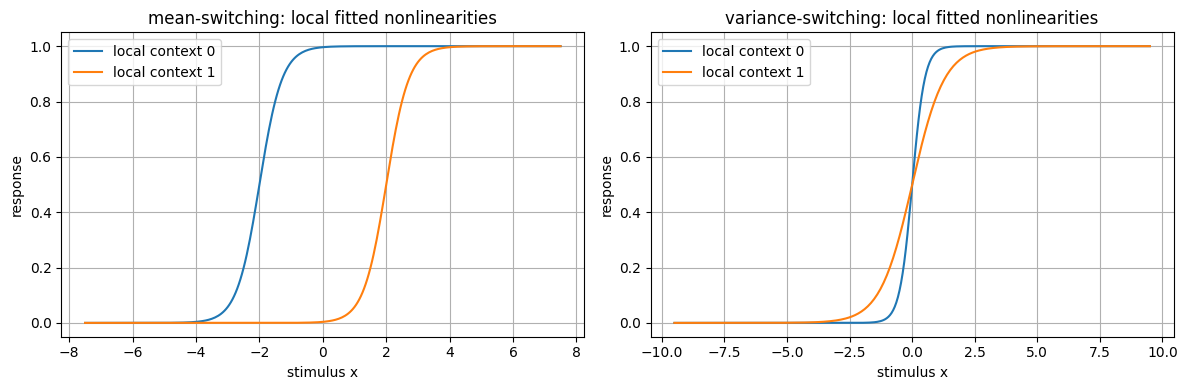

In [193]:
# ---------- fitted local nonlinearities ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, local_params_mean[0][0], local_params_mean[0][1]),
    label="local context 0",
)
axes[0].plot(
    x_grid_mean,
    logistic(x_grid_mean, local_params_mean[1][0], local_params_mean[1][1]),
    label="local context 1",
)
axes[0].set_title("mean-switching: local fitted nonlinearities")
axes[0].set_xlabel("stimulus x")
axes[0].set_ylabel("response")
axes[0].legend()

axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, local_params_var[0][0], local_params_var[0][1]),
    label="local context 0",
)
axes[1].plot(
    x_grid_var,
    logistic(x_grid_var, local_params_var[1][0], local_params_var[1][1]),
    label="local context 1",
)
axes[1].set_title("variance-switching: local fitted nonlinearities")
axes[1].set_xlabel("stimulus x")
axes[1].set_ylabel("response")
axes[1].legend()

plt.tight_layout()
plt.show()

In [194]:
# ---------- hysteresis + refractory settings ----------

# refractory:
# number of time steps after a switch during which another switch is forbidden
refractory_default = 5
refractory_grid = [0, 2, 5, 10, 20]

# hysteresis:
# switch to context 1 only if P(1) > tau_high
# switch to context 0 only if P(1) < tau_low
tau_low_default = 0.35
tau_high_default = 0.65

hysteresis_grid = [
    (0.50, 0.50),   # effectively no hysteresis / plain threshold at 0.5
    (0.40, 0.60),
    (0.35, 0.65),
    (0.30, 0.70),
]

# combined sweep grid for "both"
combined_grid = [
    (0.50, 0.50, 0),
    (0.40, 0.60, 2),
    (0.35, 0.65, 5),
    (0.30, 0.70, 10),
]

In [195]:
# ---------- baseline strategy comparison in default environments ----------

_, baseline_summary_mean = evaluate_baseline_strategies(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
)

_, baseline_summary_var = evaluate_baseline_strategies(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
)

display(baseline_summary_mean)
display(baseline_summary_var)

,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,mean_mismatch_duration_mean,mismatched_mse_mean
0,oracle,0.286008,0.006979,NaN,NaN,NaN
1,adaptive_local,0.816511,0.023477,0.053722,2.637157,10.199162
2,static,0.839311,0.011422,NaN,NaN,NaN


,strategy,global_mse_mean,global_mse_std,mismatch_rate_mean,mean_mismatch_duration_mean,mismatched_mse_mean
0,oracle,0.538827,0.113480,NaN,NaN,NaN
1,adaptive_local,0.651979,0.122299,0.171944,5.753751,1.263547
2,static,0.685614,0.102621,NaN,NaN,NaN


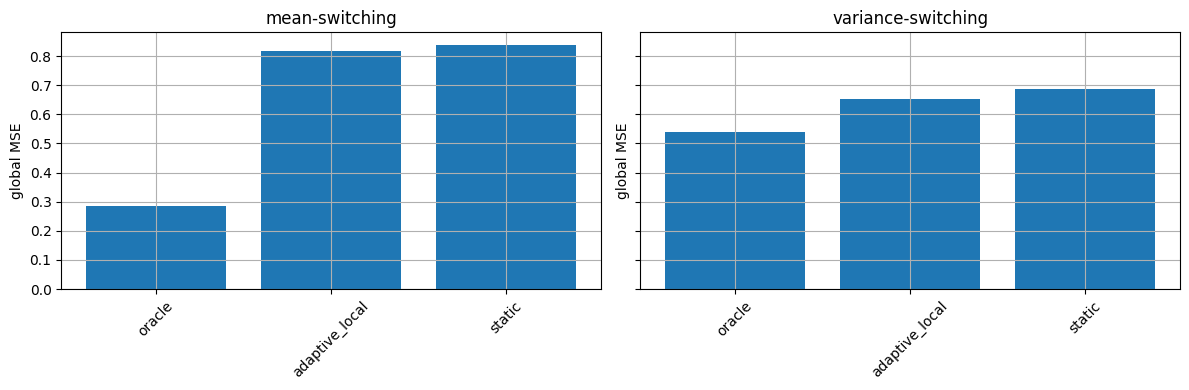

In [196]:
# ---------- baseline comparison plots ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, summary_df, title in [
    (axes[0], baseline_summary_mean, "mean-switching"),
    (axes[1], baseline_summary_var, "variance-switching"),
]:
    ax.bar(summary_df["strategy"], summary_df["global_mse_mean"])
    ax.set_title(title)
    ax.set_ylabel("global MSE")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [197]:
# ---------- switching-mode comparisons in default environments ----------

_, switching_summary_mean = evaluate_switching_modes(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
)

_, switching_summary_var = evaluate_switching_modes(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
)

display(switching_summary_mean)
display(switching_summary_var)

,mode,global_mse_mean,global_mse_std,mismatch_rate_mean,mean_mismatch_duration_mean,mismatched_mse_mean
0,hysteresis,0.805652,0.023604,0.053833,4.149864,9.989200
1,instant,0.816511,0.023477,0.053722,2.637157,10.199162
2,refractory,0.927327,0.048460,0.066444,4.680088,9.969866


,mode,global_mse_mean,global_mse_std,mismatch_rate_mean,mean_mismatch_duration_mean,mismatched_mse_mean
0,hysteresis,0.655215,0.118908,0.174944,13.678285,1.286346
1,instant,0.651979,0.122299,0.171944,5.753751,1.263547
2,refractory,0.656676,0.112278,0.181722,9.324535,1.240511


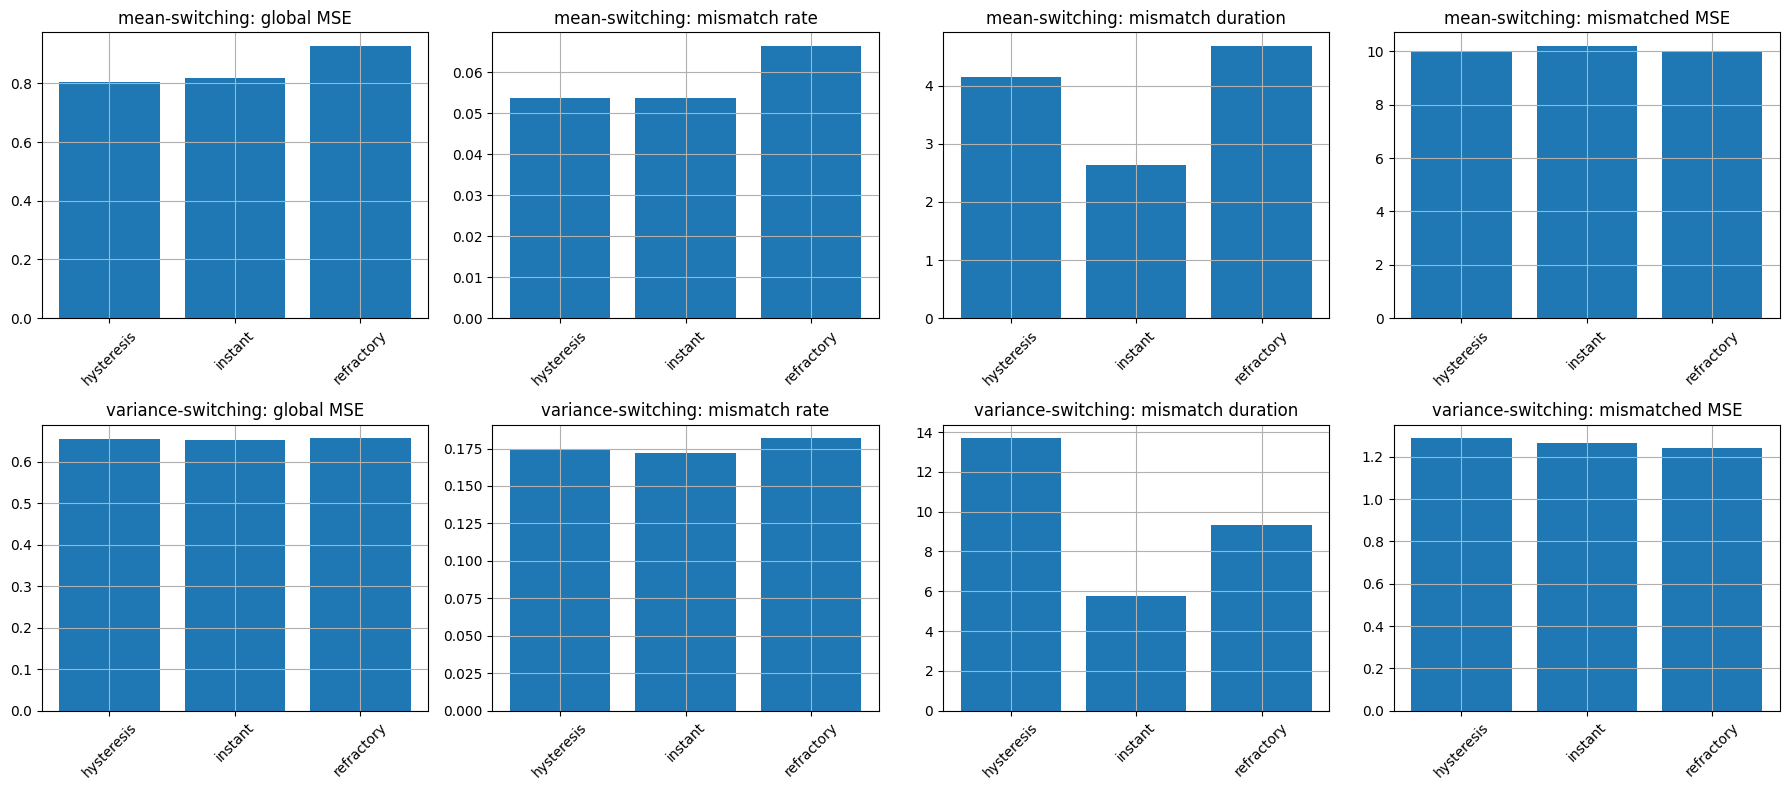

In [198]:
# ---------- main switching comparison plots ----------

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row_idx, (summary_df, env_name) in enumerate([
    (switching_summary_mean, "mean-switching"),
    (switching_summary_var, "variance-switching"),
]):
    axes[row_idx, 0].bar(summary_df["mode"], summary_df["global_mse_mean"])
    axes[row_idx, 0].set_title(f"{env_name}: global MSE")

    axes[row_idx, 1].bar(summary_df["mode"], summary_df["mismatch_rate_mean"])
    axes[row_idx, 1].set_title(f"{env_name}: mismatch rate")

    axes[row_idx, 2].bar(summary_df["mode"], summary_df["mean_mismatch_duration_mean"])
    axes[row_idx, 2].set_title(f"{env_name}: mismatch duration")

    axes[row_idx, 3].bar(summary_df["mode"], summary_df["mismatched_mse_mean"])
    axes[row_idx, 3].set_title(f"{env_name}: mismatched MSE")

    for j in range(4):
        axes[row_idx, j].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [199]:
# ---------- hysteresis sweep in local adaptive model ----------

rows = []

for tau_low_now, tau_high_now in hysteresis_grid:
    _, mean_summary_now = evaluate_switching_modes(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        seeds=seed_list,
    )
    _, var_summary_now = evaluate_switching_modes(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        seeds=seed_list,
    )

    # rerun directly at the current hysteresis setting
    mean_rows = []
    var_rows = []

    for seed_now in seed_list:
        out_mean = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_mean_default,
            x_grid=x_grid_mean,
            local_params=local_params_mean,
            static_params=static_params_mean,
            target_params=static_params_mean,
            gamma=0.0,
            seed=seed_now,
            adaptation_mode="hysteresis",
            tau_low=tau_low_now,
            tau_high=tau_high_now,
        )
        out_var = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_var_default,
            x_grid=x_grid_var,
            local_params=local_params_var,
            static_params=static_params_var,
            target_params=static_params_var,
            gamma=0.0,
            seed=seed_now,
            adaptation_mode="hysteresis",
            tau_low=tau_low_now,
            tau_high=tau_high_now,
        )
        mean_rows.append(out_mean)
        var_rows.append(out_var)

    rows.append({
        "env": "mean-switching",
        "threshold_pair": f"({tau_low_now:.2f},{tau_high_now:.2f})",
        "tau_low": tau_low_now,
        "tau_high": tau_high_now,
        "global_mse": np.mean([o["global_mse"] for o in mean_rows]),
        "mismatch_rate": np.mean([o["mismatch_rate"] for o in mean_rows]),
        "mean_mismatch_duration": np.mean([o["mean_mismatch_duration"] for o in mean_rows]),
        "mismatched_mse": np.mean([o["mismatched_mse"] for o in mean_rows]),
    })
    rows.append({
        "env": "variance-switching",
        "threshold_pair": f"({tau_low_now:.2f},{tau_high_now:.2f})",
        "tau_low": tau_low_now,
        "tau_high": tau_high_now,
        "global_mse": np.mean([o["global_mse"] for o in var_rows]),
        "mismatch_rate": np.mean([o["mismatch_rate"] for o in var_rows]),
        "mean_mismatch_duration": np.mean([o["mean_mismatch_duration"] for o in var_rows]),
        "mismatched_mse": np.mean([o["mismatched_mse"] for o in var_rows]),
    })

hysteresis_sweep_df = pd.DataFrame(rows)
display(hysteresis_sweep_df)

,env,threshold_pair,tau_low,tau_high,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean-switching,"(0.50,0.50)",0.50,0.50,0.816511,0.053722,2.637157,10.199162
1,variance-switching,"(0.50,0.50)",0.50,0.50,0.651979,0.171944,5.753751,1.263547
2,mean-switching,"(0.40,0.60)",0.40,0.60,0.815126,0.054778,3.538620,9.973956
3,variance-switching,"(0.40,0.60)",0.40,0.60,0.657836,0.178556,11.230390,1.282632
4,mean-switching,"(0.35,0.65)",0.35,0.65,0.805652,0.053833,4.149864,9.989200
5,variance-switching,"(0.35,0.65)",0.35,0.65,0.655215,0.174944,13.678285,1.286346
6,mean-switching,"(0.30,0.70)",0.30,0.70,0.812224,0.055000,4.523266,9.903926
7,variance-switching,"(0.30,0.70)",0.30,0.70,0.654712,0.178389,15.767627,1.245028


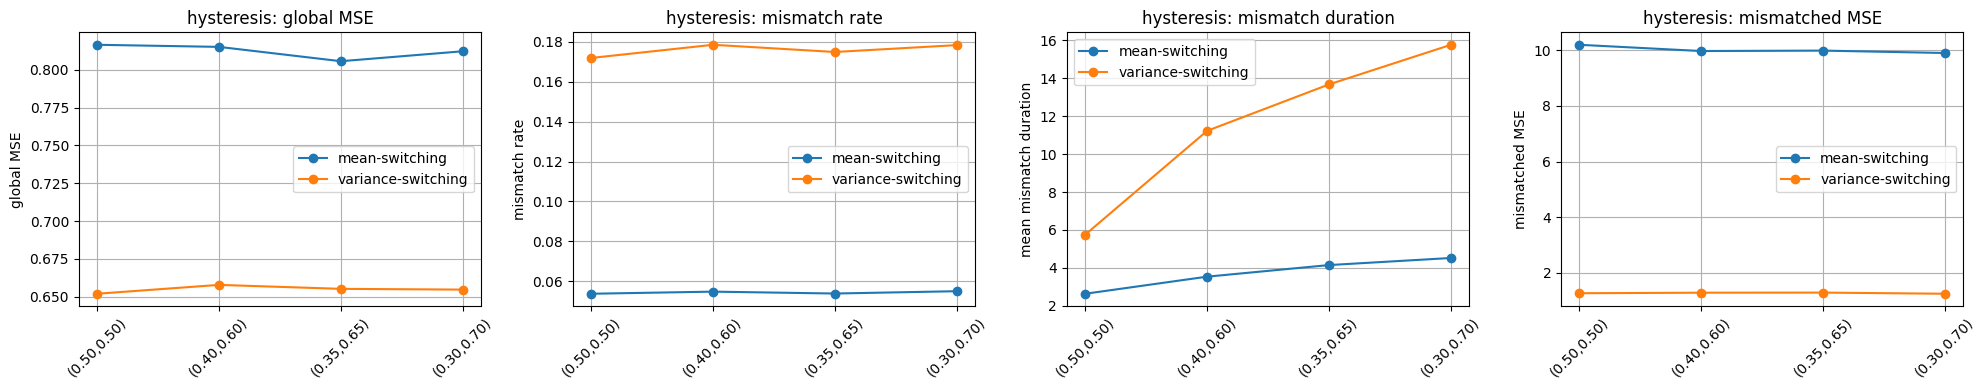

In [200]:
# ---------- hysteresis sweep plots ----------

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for env_name in ["mean-switching", "variance-switching"]:
    df_now = hysteresis_sweep_df[hysteresis_sweep_df["env"] == env_name]
    axes[0].plot(df_now["threshold_pair"], df_now["global_mse"], marker="o", label=env_name)
    axes[1].plot(df_now["threshold_pair"], df_now["mismatch_rate"], marker="o", label=env_name)
    axes[2].plot(df_now["threshold_pair"], df_now["mean_mismatch_duration"], marker="o", label=env_name)
    axes[3].plot(df_now["threshold_pair"], df_now["mismatched_mse"], marker="o", label=env_name)

for ax, title, ylabel in zip(
    axes,
    ["hysteresis: global MSE", "hysteresis: mismatch rate", "hysteresis: mismatch duration", "hysteresis: mismatched MSE"],
    ["global MSE", "mismatch rate", "mean mismatch duration", "mismatched MSE"],
):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

In [201]:
# ---------- refractory sweep in local adaptive model ----------

rows = []

for refractory_now in refractory_grid:
    mean_rows = []
    var_rows = []

    for seed_now in seed_list:
        out_mean = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_mean_default,
            x_grid=x_grid_mean,
            local_params=local_params_mean,
            static_params=static_params_mean,
            target_params=static_params_mean,
            gamma=0.0,
            seed=seed_now,
            adaptation_mode="refractory",
            refractory_length=refractory_now,
        )
        out_var = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_var_default,
            x_grid=x_grid_var,
            local_params=local_params_var,
            static_params=static_params_var,
            target_params=static_params_var,
            gamma=0.0,
            seed=seed_now,
            adaptation_mode="refractory",
            refractory_length=refractory_now,
        )
        mean_rows.append(out_mean)
        var_rows.append(out_var)

    rows.append({
        "env": "mean-switching",
        "refractory_length": refractory_now,
        "global_mse": np.mean([o["global_mse"] for o in mean_rows]),
        "mismatch_rate": np.mean([o["mismatch_rate"] for o in mean_rows]),
        "mean_mismatch_duration": np.mean([o["mean_mismatch_duration"] for o in mean_rows]),
        "mismatched_mse": np.mean([o["mismatched_mse"] for o in mean_rows]),
    })
    rows.append({
        "env": "variance-switching",
        "refractory_length": refractory_now,
        "global_mse": np.mean([o["global_mse"] for o in var_rows]),
        "mismatch_rate": np.mean([o["mismatch_rate"] for o in var_rows]),
        "mean_mismatch_duration": np.mean([o["mean_mismatch_duration"] for o in var_rows]),
        "mismatched_mse": np.mean([o["mismatched_mse"] for o in var_rows]),
    })

refractory_sweep_df = pd.DataFrame(rows)
display(refractory_sweep_df)

,env,refractory_length,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean-switching,0,0.816511,0.053722,2.637157,10.199162
1,variance-switching,0,0.651979,0.171944,5.753751,1.263547
2,mean-switching,2,0.837350,0.056667,3.736035,10.049352
3,variance-switching,2,0.657275,0.176833,7.709810,1.257395
4,mean-switching,5,0.927327,0.066444,4.680088,9.969866
5,variance-switching,5,0.656676,0.181722,9.324535,1.240511
6,mean-switching,10,1.076604,0.083833,6.148171,9.749853
7,variance-switching,10,0.664125,0.199000,11.749300,1.190515
8,mean-switching,20,1.443072,0.119667,9.510314,9.986631
9,variance-switching,20,0.688655,0.235611,15.941747,1.183334


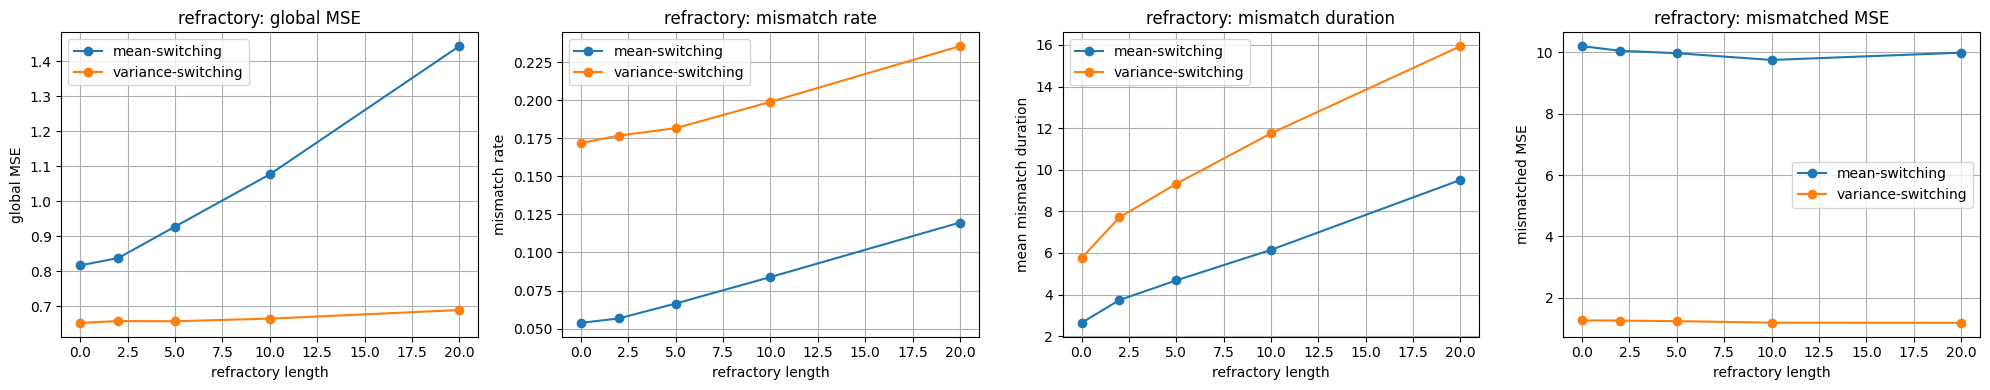

In [202]:
# ---------- refractory sweep plots ----------

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for env_name in ["mean-switching", "variance-switching"]:
    df_now = refractory_sweep_df[refractory_sweep_df["env"] == env_name]
    axes[0].plot(df_now["refractory_length"], df_now["global_mse"], marker="o", label=env_name)
    axes[1].plot(df_now["refractory_length"], df_now["mismatch_rate"], marker="o", label=env_name)
    axes[2].plot(df_now["refractory_length"], df_now["mean_mismatch_duration"], marker="o", label=env_name)
    axes[3].plot(df_now["refractory_length"], df_now["mismatched_mse"], marker="o", label=env_name)

axes[0].set_title("refractory: global MSE")
axes[0].set_xlabel("refractory length")
axes[0].set_ylabel("global MSE")
axes[0].legend()

axes[1].set_title("refractory: mismatch rate")
axes[1].set_xlabel("refractory length")
axes[1].set_ylabel("mismatch rate")
axes[1].legend()

axes[2].set_title("refractory: mismatch duration")
axes[2].set_xlabel("refractory length")
axes[2].set_ylabel("mean mismatch duration")
axes[2].legend()

axes[3].set_title("refractory: mismatched MSE")
axes[3].set_xlabel("refractory length")
axes[3].set_ylabel("mismatched MSE")
axes[3].legend()

plt.tight_layout()
plt.show()

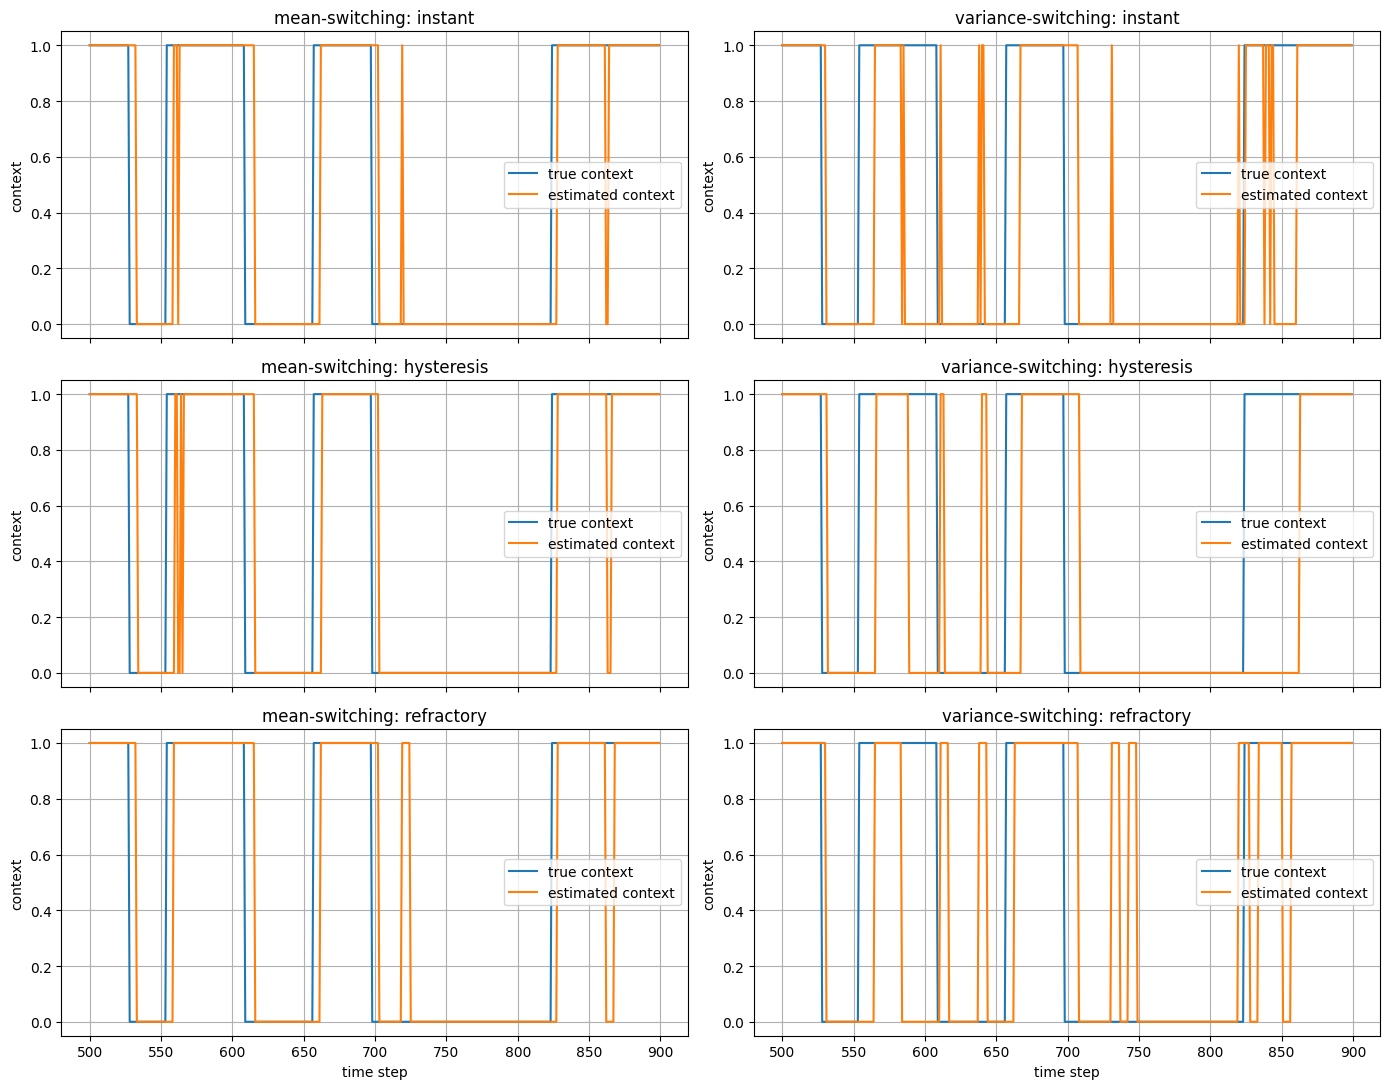

In [203]:
# ---------- optional traces for instant, hysteresis, and refractory ----------

show_slice = slice(500, 900)

mean_base_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="instant",
)

mean_hyst_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="hysteresis",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
)

mean_refr_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
    target_params=static_params_mean,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="refractory",
    refractory_length=refractory_default,
)

var_base_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="instant",
)

var_hyst_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="hysteresis",
    tau_low=tau_low_default,
    tau_high=tau_high_default,
)

var_refr_out = run_strategy_one_neuron(
    strategy_name="adaptive",
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
    target_params=static_params_var,
    gamma=0.0,
    p_switch=p_switch_main,
    seed=123,
    adaptation_mode="refractory",
    refractory_length=refractory_default,
)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)

for ax, out, title in [
    (axes[0, 0], mean_base_out, "mean-switching: instant"),
    (axes[1, 0], mean_hyst_out, "mean-switching: hysteresis"),
    (axes[2, 0], mean_refr_out, "mean-switching: refractory"),
    (axes[0, 1], var_base_out, "variance-switching: instant"),
    (axes[1, 1], var_hyst_out, "variance-switching: hysteresis"),
    (axes[2, 1], var_refr_out, "variance-switching: refractory"),
]:
    df = out["df"].iloc[show_slice]
    ax.plot(df["t"], df["true_context"], label="true context")
    ax.plot(df["t"], df["estimated_context"], label="estimated context")
    ax.set_title(title)
    ax.set_ylabel("context")
    ax.legend()

axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")

plt.tight_layout()
plt.show()

In [204]:
# ---------- mixed sweep setup ----------

mixed_env_configs = {
    "mean": {
        "weak": {
            "contexts": make_mean_contexts(delta=0.75, sigma=1.0),
            "label": "mean-switching",
        },
        "strong": {
            "contexts": make_mean_contexts(delta=2.0, sigma=1.0),
            "label": "mean-switching",
        },
    },
    "variance": {
        "weak": {
            "contexts": make_variance_contexts(sigma_low=0.9, sigma_high=1.4),
            "label": "variance-switching",
        },
        "strong": {
            "contexts": make_variance_contexts(sigma_low=0.7, sigma_high=1.8),
            "label": "variance-switching",
        },
    },
}

mixed_mode_configs = {
    "instant": {
        "adaptation_mode": "instant",
        "tau_low": 0.35,
        "tau_high": 0.65,
        "refractory_length": 0,
    },
    "hysteresis": {
        "adaptation_mode": "hysteresis",
        "tau_low": 0.35,
        "tau_high": 0.65,
        "refractory_length": 0,
    },
    "refractory": {
        "adaptation_mode": "refractory",
        "tau_low": 0.35,
        "tau_high": 0.65,
        "refractory_length": 20,
    },
}

In [205]:
# ---------- run mixed sweep ----------

rows = []

for env_type, separation_dict in mixed_env_configs.items():
    for separation, env_cfg in separation_dict.items():
        contexts_now = env_cfg["contexts"]

        fit_now = fit_codebook_for_contexts(contexts_now)
        x_grid_now = fit_now["x_grid"]
        local_params_now = fit_now["local_params"]
        static_params_now = fit_now["static_params"]

        for mode, mode_cfg in mixed_mode_configs.items():
            seed_rows = []

            for seed_now in seed_list:
                out = run_strategy_one_neuron(
                    strategy_name="adaptive",
                    contexts=contexts_now,
                    x_grid=x_grid_now,
                    local_params=local_params_now,
                    static_params=static_params_now,
                    target_params=static_params_now,
                    gamma=0.0,
                    p_switch=p_switch_main,
                    n_steps=n_steps_main,
                    burn_in=burn_in_main,
                    response_sd=response_sd_default,
                    seed=seed_now,
                    adaptation_mode=mode_cfg["adaptation_mode"],
                    tau_low=mode_cfg["tau_low"],
                    tau_high=mode_cfg["tau_high"],
                    refractory_length=mode_cfg["refractory_length"],
                )

                seed_rows.append({
                    "global_mse": out["global_mse"],
                    "mismatch_rate": out["mismatch_rate"],
                    "mean_mismatch_duration": out["mean_mismatch_duration"],
                    "mismatched_mse": out["mismatched_mse"],
                })

            seed_df = pd.DataFrame(seed_rows)

            rows.append({
                "env_type": env_type,
                "separation": separation,
                "mode": mode,
                "global_mse": seed_df["global_mse"].mean(),
                "mismatch_rate": seed_df["mismatch_rate"].mean(),
                "mean_mismatch_duration": seed_df["mean_mismatch_duration"].mean(),
                "mismatched_mse": seed_df["mismatched_mse"].mean(),
            })

mixed_sweep_df = pd.DataFrame(rows)
mixed_sweep_df["mode"] = pd.Categorical(
    mixed_sweep_df["mode"],
    categories=["instant", "hysteresis", "refractory"],
    ordered=True,
)

display(mixed_sweep_df)

,env_type,separation,mode,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse
0,mean,weak,instant,0.308685,0.153889,5.359288,0.431259
1,mean,weak,hysteresis,0.308830,0.155722,11.481170,0.432581
2,mean,weak,refractory,0.318473,0.215611,15.100784,0.445366
3,mean,strong,instant,0.399940,0.066056,2.904561,2.029937
4,mean,strong,hysteresis,0.395658,0.066667,4.887883,1.968785
5,mean,strong,refractory,0.516779,0.139444,10.574504,1.960502
6,variance,weak,instant,0.436798,0.275500,7.352447,0.534432
7,variance,weak,hysteresis,0.438757,0.284778,27.503071,0.540450
8,variance,weak,refractory,0.440138,0.308778,19.958531,0.525850
9,variance,strong,instant,0.651979,0.171944,5.753751,1.263547


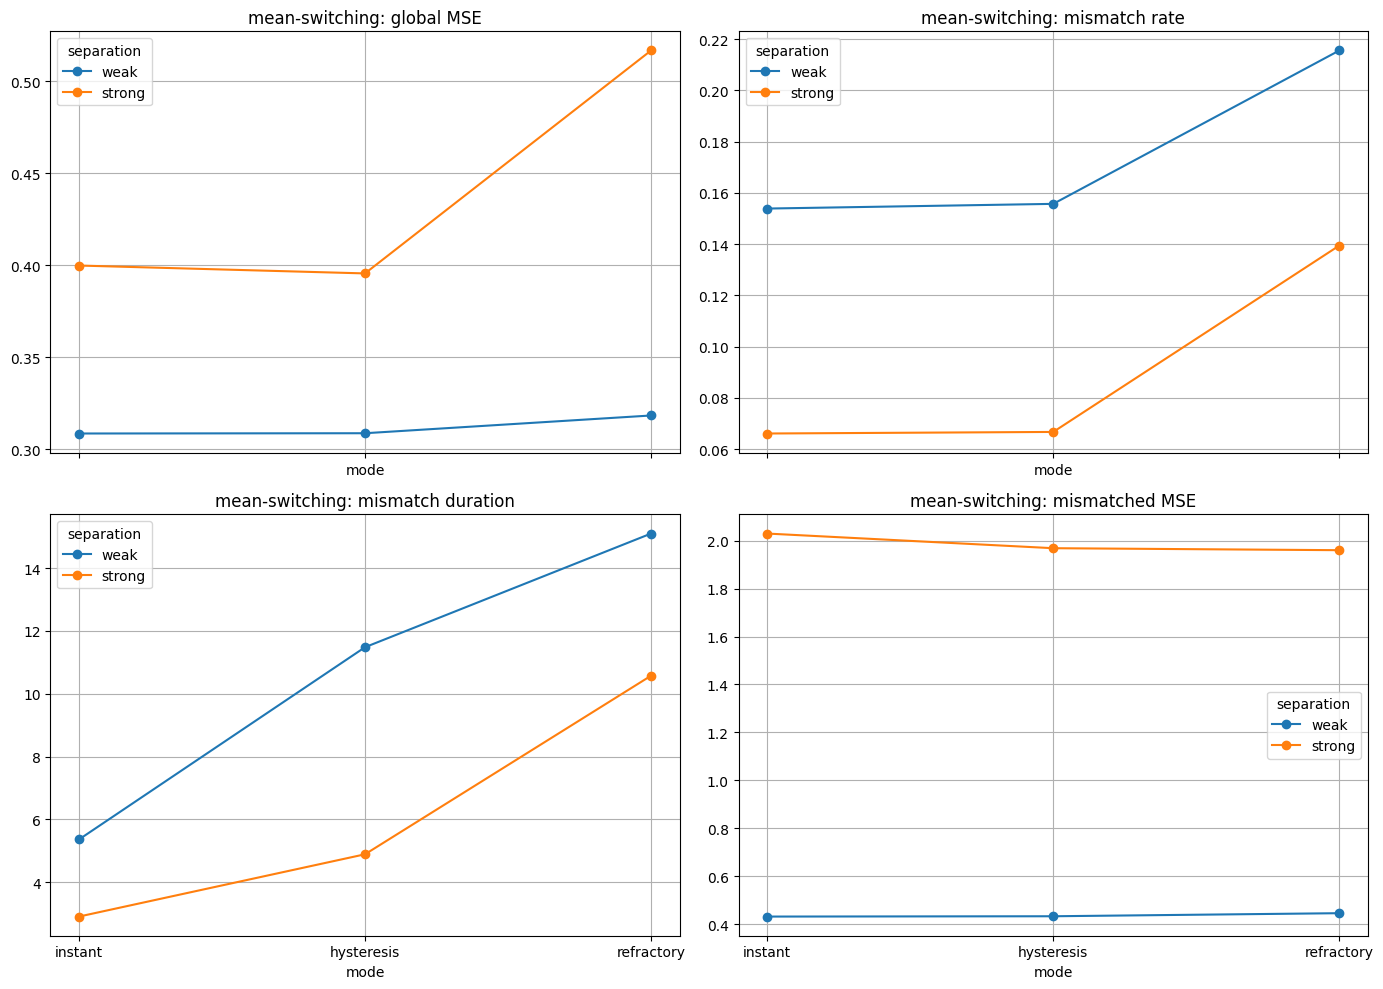

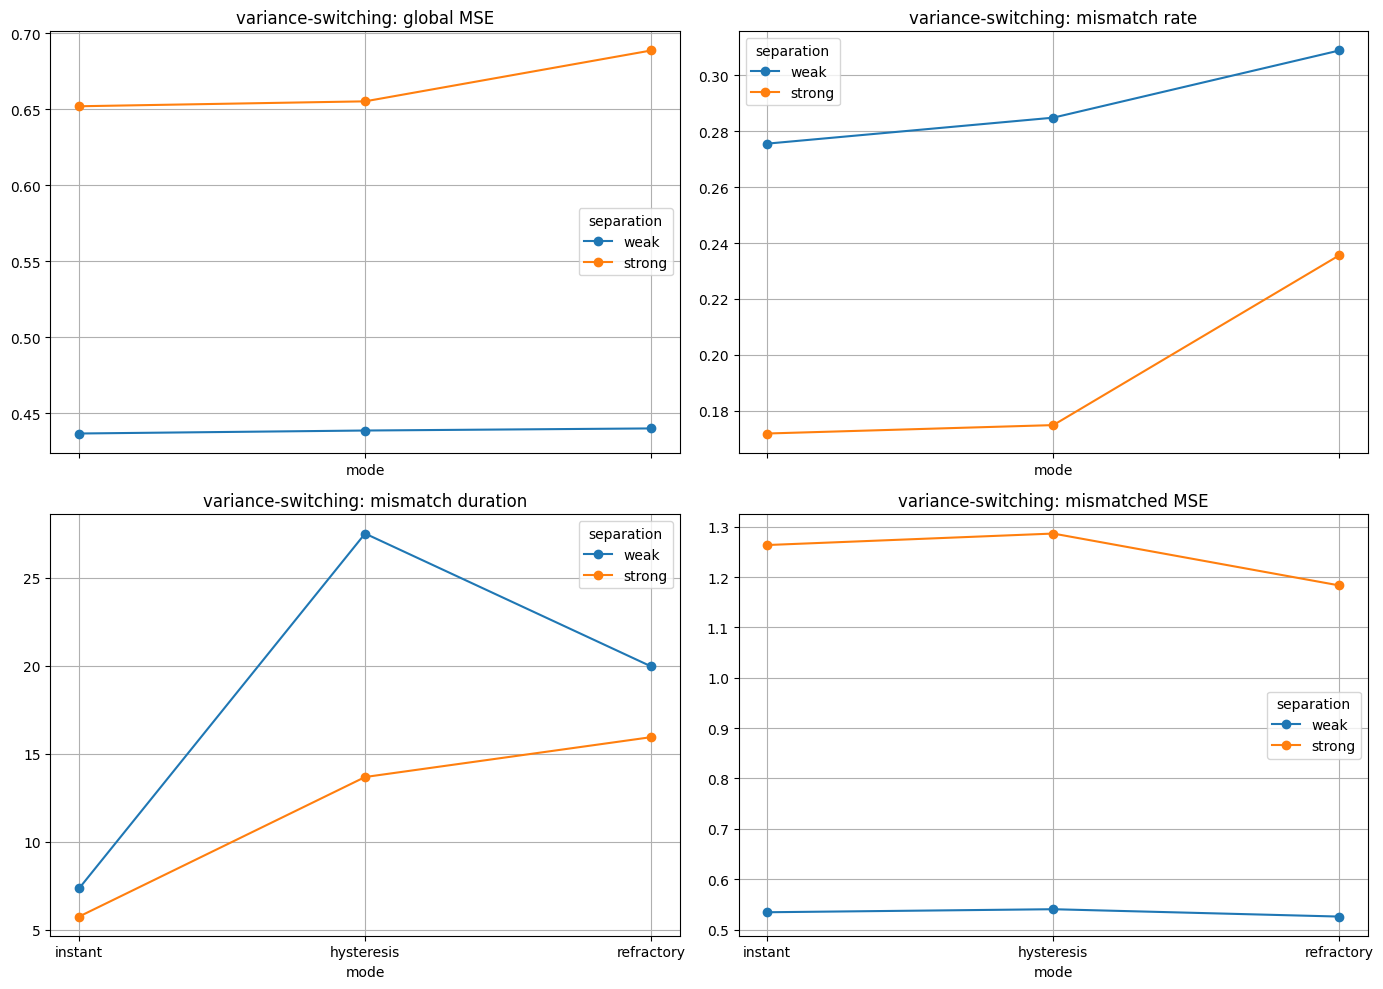

In [206]:
# ---------- plot mixed sweep results ----------

for env_type in ["mean", "variance"]:
    df_env = mixed_sweep_df[mixed_sweep_df["env_type"] == env_type].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    for separation in ["weak", "strong"]:
        df_sep = df_env[df_env["separation"] == separation].sort_values("mode")

        axes[0, 0].plot(df_sep["mode"], df_sep["global_mse"], marker="o", label=separation)
        axes[0, 1].plot(df_sep["mode"], df_sep["mismatch_rate"], marker="o", label=separation)
        axes[1, 0].plot(df_sep["mode"], df_sep["mean_mismatch_duration"], marker="o", label=separation)
        axes[1, 1].plot(df_sep["mode"], df_sep["mismatched_mse"], marker="o", label=separation)

    axes[0, 0].set_title(f"{env_type}-switching: global MSE")
    axes[0, 1].set_title(f"{env_type}-switching: mismatch rate")
    axes[1, 0].set_title(f"{env_type}-switching: mismatch duration")
    axes[1, 1].set_title(f"{env_type}-switching: mismatched MSE")

    for ax in axes.ravel():
        ax.set_xlabel("mode")
        ax.legend(title="separation")

    plt.tight_layout()
    plt.show()